In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
nb_results = pd.read_csv(
    "../outputs/results/experiment_1_naive_bayes.csv"
)

lr_results = pd.read_csv(
    "../outputs/results/experiment_2_logistic_regression.csv"
)

svm_results = pd.read_csv(
    "../outputs/results/experiment_3_linear_svm.csv"
)
comparison_df = pd.concat(
    [
        nb_results,
        lr_results,
        svm_results
    ],
    ignore_index=True
)

comparison_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Multinomial Naive Bayes,0.993354,0.993538,0.992986,0.993151,0.993546,0.993354,0.993347
1,Logistic Regression,0.994481,0.994487,0.994079,0.994181,0.994654,0.994481,0.994474
2,Linear SVM,0.995382,0.995351,0.994976,0.995068,0.995534,0.995382,0.995370


In [4]:
main_metrics = comparison_df[
    [
        "model",
        "accuracy",
        "f1_macro",
        "f1_weighted"
    ]
].copy()

main_metrics

,model,accuracy,f1_macro,f1_weighted
0,Multinomial Naive Bayes,0.993354,0.993151,0.993347
1,Logistic Regression,0.994481,0.994181,0.994474
2,Linear SVM,0.995382,0.995068,0.995370


In [5]:
main_metrics_sorted = main_metrics.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

main_metrics_sorted

,model,accuracy,f1_macro,f1_weighted
0,Linear SVM,0.995382,0.995068,0.995370
1,Logistic Regression,0.994481,0.994181,0.994474
2,Multinomial Naive Bayes,0.993354,0.993151,0.993347


In [6]:
display_df = main_metrics.copy()

display_df["accuracy"] *= 100
display_df["f1_macro"] *= 100
display_df["f1_weighted"] *= 100

display_df = display_df.round(2)

display_df

,model,accuracy,f1_macro,f1_weighted
0,Multinomial Naive Bayes,99.34,99.32,99.33
1,Logistic Regression,99.45,99.42,99.45
2,Linear SVM,99.54,99.51,99.54


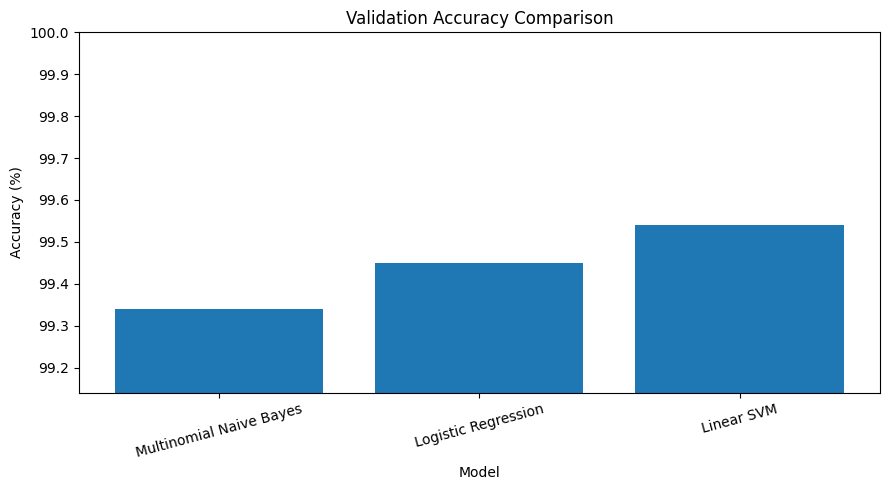

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    display_df["model"],
    display_df["accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(
    display_df["accuracy"].min() - 0.2,
    100
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

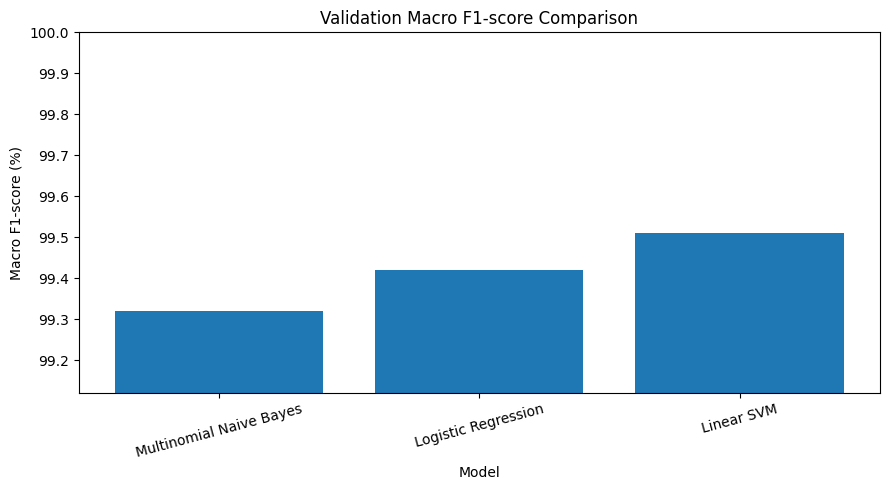

In [8]:
plt.figure(figsize=(9, 5))

plt.bar(
    display_df["model"],
    display_df["f1_macro"]
)

plt.title("Validation Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score (%)")

plt.ylim(
    display_df["f1_macro"].min() - 0.2,
    100
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [9]:
best_model_row = comparison_df.loc[
    comparison_df["f1_macro"].idxmax()
]

print("Best model:", best_model_row["model"])
print(
    f"Validation Accuracy: "
    f"{best_model_row['accuracy']:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{best_model_row['f1_macro']:.4f}"
)

Best model: Linear SVM
Validation Accuracy: 0.9954
Validation Macro F1: 0.9951


## Lựa chọn mô hình

Ba mô hình được đánh giá trên cùng tập validation và sử dụng cùng bộ đặc trưng TF-IDF kết hợp Character N-gram.

Trong ba thử nghiệm, Linear SVM đạt Accuracy và Macro F1-score cao nhất. Vì vậy, Linear SVM được lựa chọn làm mô hình nhận diện ngôn ngữ cho hệ thống.

Tập test chưa được sử dụng trong quá trình lựa chọn mô hình và được giữ riêng để thực hiện đánh giá cuối cùng.

In [11]:
test_df = pd.read_csv(
    "../data/processed/test_processed.csv"
)

print(
    "Test shape:",
    test_df.shape
)

test_df.head()

Test shape: (9172, 3)


,labels,text,clean_text
0,nl,Een man zingt en speelt gitaar.,Een man zingt en speelt gitaar.
1,nl,De technologisch geplaatste Nasdaq Composite I...,De technologisch geplaatste Nasdaq Composite I...
2,es,Es muy resistente la parte trasera rígida y lo...,Es muy resistente la parte trasera rígida y lo...
3,it,"""In tanti modi diversi, l'abilità artistica de...","""In tanti modi diversi, l'abilità artistica de..."
4,ar,منحدر يواجه العديد من النقاشات المتجهه إزاء ال...,منحدر يواجه العديد من النقاشات المتجهه إزاء ال...


In [12]:
X_test = test_df["clean_text"]
y_test = test_df["labels"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (9172,)
y_test: (9172,)


In [13]:
tfidf_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.joblib"
)

svm_model = joblib.load(
    "../models/linear_svm_model.joblib"
)

print("Vectorizer loaded!")
print("Linear SVM loaded!")

Vectorizer loaded!
Linear SVM loaded!


In [14]:
X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

print(
    "Test TF-IDF:",
    X_test_tfidf.shape
)

Test TF-IDF: (9172, 100000)


In [15]:
y_test_pred = svm_model.predict(
    X_test_tfidf
)

In [17]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision_macro = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall_macro = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1_macro = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_precision_weighted = precision_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_recall_weighted = recall_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_f1_weighted = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)
print("=== FINAL TEST - LINEAR SVM ===")

print(
    f"Accuracy:           "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro Precision:    "
    f"{test_precision_macro:.4f}"
)

print(
    f"Macro Recall:       "
    f"{test_recall_macro:.4f}"
)

print(
    f"Macro F1-score:     "
    f"{test_f1_macro:.4f}"
)

print(
    f"Weighted Precision: "
    f"{test_precision_weighted:.4f}"
)

print(
    f"Weighted Recall:    "
    f"{test_recall_weighted:.4f}"
)

print(
    f"Weighted F1-score:  "
    f"{test_f1_weighted:.4f}"
)

=== FINAL TEST - LINEAR SVM ===
Accuracy:           0.9949
Macro Precision:    0.9949
Macro Recall:       0.9947
Macro F1-score:     0.9947
Weighted Precision: 0.9951
Weighted Recall:    0.9949
Weighted F1-score:  0.9949


In [18]:
correct = (
    y_test.values == y_test_pred
).sum()

incorrect = (
    y_test.values != y_test_pred
).sum()

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Total:", len(y_test))

print(
    "Accuracy check:",
    correct / len(y_test)
)

Correct: 9125
Incorrect: 47
Total: 9172
Accuracy check: 0.994875708678587


In [19]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

          ar     1.0000    0.9977    0.9989       440
          bg     0.9977    1.0000    0.9989       440
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       440
          en     0.9960    1.0000    0.9980       500
          es     0.9980    0.9980    0.9980       499
          fr     0.9980    1.0000    0.9990       497
          hi     1.0000    0.9636    0.9815       440
          it     0.9933    0.9955    0.9944       446
          ja     1.0000    1.0000    1.0000       500
          nl     0.9955    0.9978    0.9966       445
          pl     1.0000    0.9932    0.9966       440
          pt     0.9933    0.9978    0.9955       448
          ru     1.0000    0.9977    0.9989       440
          sw     0.9359    0.9955    0.9648       440
          th     1.0000    0.9977    0.9989       440
          tr     0.9910    1.0000    0.9955       440
          ur     1.0000    

In [20]:
test_report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True
)

test_report_df = pd.DataFrame(
    test_report
).transpose()

test_report_df

,precision,recall,f1-score,support
ar,1.000000,0.997727,0.998862,440.000000
bg,0.997732,1.000000,0.998865,440.000000
de,1.000000,1.000000,1.000000,500.000000
el,1.000000,1.000000,1.000000,440.000000
en,0.996016,1.000000,0.998004,500.000000
es,0.997996,0.997996,0.997996,499.000000
fr,0.997992,1.000000,0.998995,497.000000
hi,1.000000,0.963636,0.981481,440.000000
it,0.993289,0.995516,0.994401,446.000000
ja,1.000000,1.000000,1.000000,500.000000


In [21]:
test_language_report = test_report_df.loc[
    sorted(y_test.unique())
]

test_language_report.sort_values(
    by="f1-score"
).head(10)

,precision,recall,f1-score,support
sw,0.935897,0.995455,0.964758,440.0
ur,1.000000,0.958810,0.978972,437.0
hi,1.000000,0.963636,0.981481,440.0
it,0.993289,0.995516,0.994401,446.0
tr,0.990991,1.000000,0.995475,440.0
pt,0.993333,0.997768,0.995546,448.0
pl,1.000000,0.993182,0.996579,440.0
nl,0.995516,0.997753,0.996633,445.0
es,0.997996,0.997996,0.997996,499.0
en,0.996016,1.000000,0.998004,500.0


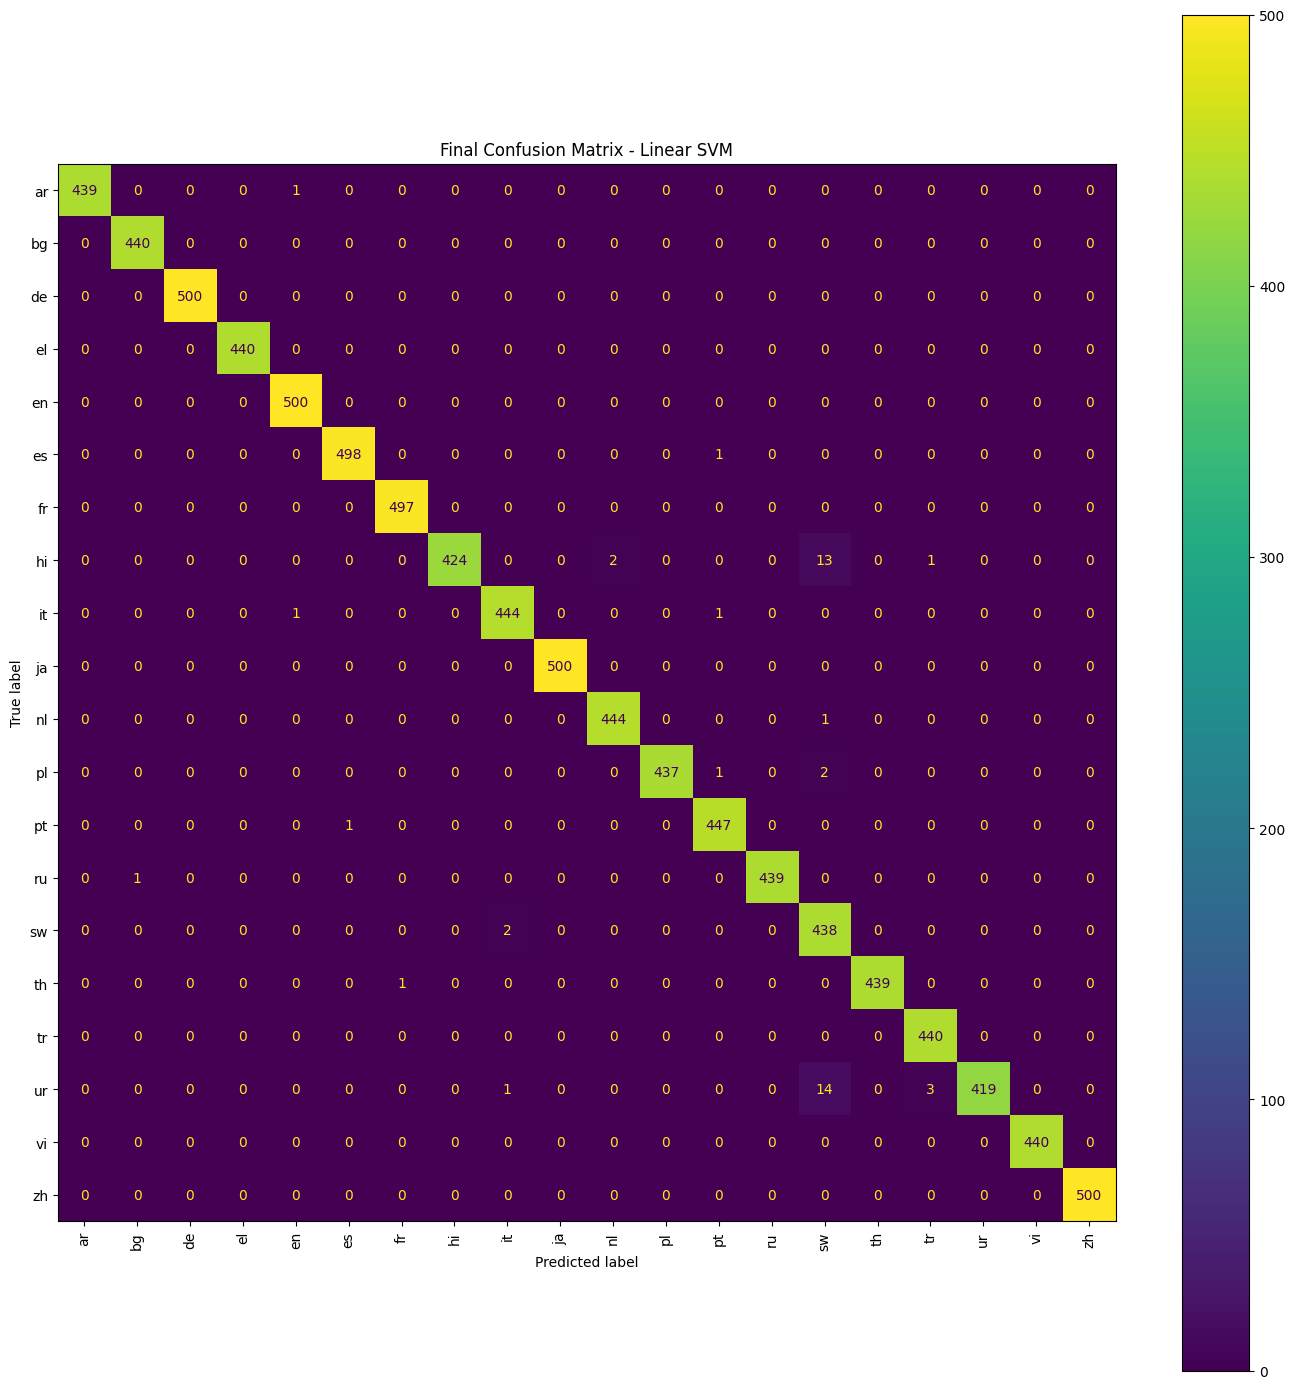

In [22]:
labels = sorted(
    y_test.unique()
)

fig, ax = plt.subplots(
    figsize=(14, 14)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=labels,
    display_labels=labels,
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Final Confusion Matrix - Linear SVM"
)

plt.tight_layout()
plt.show()

In [23]:
test_errors = test_df.copy()

test_errors["predicted"] = y_test_pred

test_errors = test_errors[
    test_errors["labels"]
    != test_errors["predicted"]
]

print(
    "Số mẫu dự đoán sai trên Test:",
    len(test_errors)
)

test_errors[
    [
        "labels",
        "predicted",
        "clean_text"
    ]
].head(30)

Số mẫu dự đoán sai trên Test: 47


,labels,predicted,clean_text
485,hi,sw,aadhunik mahilaen Romantic shira mein maheen h...
699,ur,sw,"Us din mai apna wheel ghooma raha tha, mjhe na..."
1622,hi,sw,is nivesh ne 60 gharo ka navikaran aur maamool...
1847,pl,sw,To także kwestia gustu.
1969,pl,sw,Apple iPad mini debiutuje
2076,ur,sw,"To mai gaya, mai Washington D.C. gaya aur mai ..."
2417,th,fr,คนที่ L'academie Internationale des Arts et de...
2739,hi,sw,"gupt karya ke liye, beshak, White House Counte..."
2773,hi,nl,ek graahak kee anupasthiti ke dauraan nirantar...
3068,pl,pt,Romney Wins Nevada Caucus


### Phân tích lỗi

Mô hình Linear SVM đạt kết quả cao trên tập test, tuy nhiên vẫn còn 47 mẫu được dự đoán sai trên tổng số 9.172 mẫu.

Các ngôn ngữ có F1-score thấp hơn đáng kể so với các lớp còn lại gồm Swahili (`sw`), Urdu (`ur`) và Hindi (`hi`).

Qua quan sát các mẫu dự đoán sai, một số văn bản Hindi và Urdu được viết bằng bảng chữ cái Latin thay vì hệ chữ thông thường của ngôn ngữ đó. Điều này làm giảm các đặc trưng ký tự đặc trưng mà mô hình Character N-gram có thể sử dụng để phân biệt ngôn ngữ.

Ngoài ra, một số mẫu chứa tên riêng, từ tiếng Anh hoặc nội dung pha trộn nhiều ngôn ngữ, khiến việc nhận diện trở nên khó khăn hơn.

Kết quả cho thấy mô hình hoạt động tốt trên phần lớn dữ liệu nhưng vẫn còn hạn chế đối với văn bản được Latin hóa, văn bản ngắn và văn bản có sự pha trộn ngôn ngữ.

In [24]:
final_test_results = pd.DataFrame({
    "model": [
        "Linear SVM"
    ],
    "accuracy": [
        test_accuracy
    ],
    "precision_macro": [
        test_precision_macro
    ],
    "recall_macro": [
        test_recall_macro
    ],
    "f1_macro": [
        test_f1_macro
    ],
    "precision_weighted": [
        test_precision_weighted
    ],
    "recall_weighted": [
        test_recall_weighted
    ],
    "f1_weighted": [
        test_f1_weighted
    ]
})

final_test_results

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Linear SVM,0.994876,0.994938,0.994665,0.994715,0.995079,0.994876,0.994894


In [25]:
final_test_results.to_csv(
    "../outputs/results/final_test_results.csv",
    index=False
)

print(
    "Final test results saved!"
)

Final test results saved!


In [26]:
train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

val_df = pd.read_csv(
    "../data/processed/validation_processed.csv"
)

train_val_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)

print(
    "Train + Validation:",
    train_val_df.shape
)

Train + Validation: (77854, 3)


In [27]:
X_train_val = train_val_df[
    "clean_text"
]

y_train_val = train_val_df[
    "labels"
]

In [28]:
final_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    lowercase=True,
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

In [29]:
X_train_val_tfidf = (
    final_vectorizer.fit_transform(
        X_train_val
    )
)

print(
    "Final TF-IDF:",
    X_train_val_tfidf.shape
)

Final TF-IDF: (77854, 100000)


In [30]:
final_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

final_model.fit(
    X_train_val_tfidf,
    y_train_val
)

print(
    "Final deployment model trained!"
)

Final deployment model trained!


In [31]:
joblib.dump(
    final_vectorizer,
    "../models/final_tfidf_vectorizer.joblib"
)

joblib.dump(
    final_model,
    "../models/final_language_model.joblib"
)

print(
    "Final deployment files saved!"
)

Final deployment files saved!


In [32]:
loaded_final_vectorizer = joblib.load(
    "../models/final_tfidf_vectorizer.joblib"
)

loaded_final_model = joblib.load(
    "../models/final_language_model.joblib"
)

In [33]:
samples = [
    "Hello, how are you today?",
    "Bonjour, comment allez-vous?",
    "Xin chào, hôm nay bạn khỏe không?",
    "¿Cómo estás hoy?",
    "これは日本語の文章です。",
    "这是一个中文句子。"
]

sample_vectors = (
    loaded_final_vectorizer.transform(
        samples
    )
)

predictions = (
    loaded_final_model.predict(
        sample_vectors
    )
)

for text, language in zip(
    samples,
    predictions
):
    print(
        f"{language:>3} | {text}"
    )

 en | Hello, how are you today?
 fr | Bonjour, comment allez-vous?
 vi | Xin chào, hôm nay bạn khỏe không?
 es | ¿Cómo estás hoy?
 ja | これは日本語の文章です。
 zh | 这是一个中文句子。


## Kết luận

Ba mô hình Multinomial Naive Bayes, Logistic Regression và Linear SVM đã được xây dựng và đánh giá trên cùng tập validation với cùng phương pháp trích xuất đặc trưng TF-IDF kết hợp Character N-gram.

Trong ba mô hình, Linear SVM đạt Accuracy và Macro F1-score cao nhất trên tập validation, do đó được lựa chọn làm mô hình cuối cùng cho hệ thống nhận diện ngôn ngữ.

Sau quá trình lựa chọn mô hình, Linear SVM được đánh giá một lần trên tập test độc lập nhằm đánh giá khả năng tổng quát hóa trên dữ liệu chưa xuất hiện trong quá trình huấn luyện và lựa chọn mô hình.

Sau khi hoàn tất quá trình đánh giá, mô hình triển khai được huấn luyện lại bằng dữ liệu Train và Validation nhằm tận dụng thêm dữ liệu huấn luyện. Tập test không được sử dụng trong quá trình huấn luyện mô hình triển khai.

Mô hình Linear SVM cuối cùng và TF-IDF Vectorizer tương ứng được lưu lại để sử dụng trong Project 1, nơi mô hình sẽ được triển khai thông qua REST API.